<a href="https://colab.research.google.com/github/HassaanDeveloper/AI-Internship-Advance-Tasks/blob/main/Task2/AI_ML_Intern_Advance_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
from sklearn.impute import SimpleImputer

In [ ]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Shape: (7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Missing values after cleaning: 0

Churn Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


/tmp/ipykernel_14495/2122039635.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
/tmp/ipykernel_14495/2122039635.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Churn', 'Churn'])


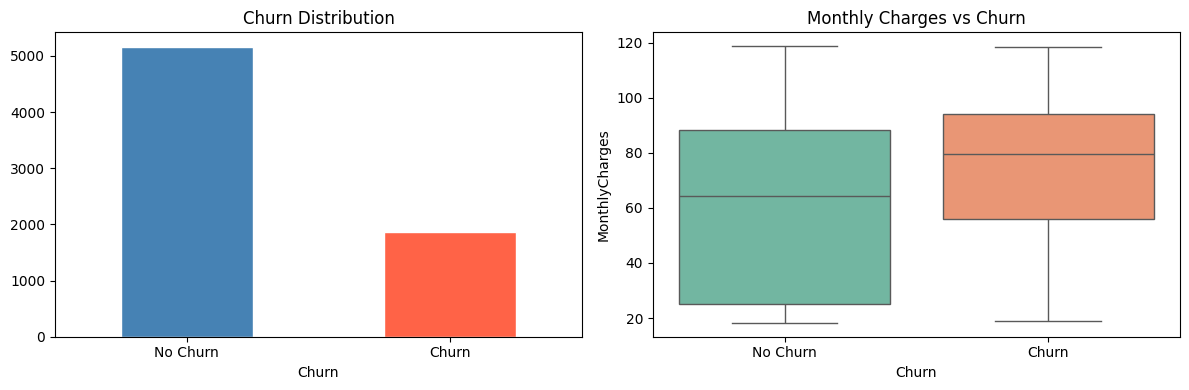

In [ ]:
# Fix TotalCharges (loaded as string, has spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Drop customerID (not useful)
df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Missing values after cleaning:", df.isnull().sum().sum())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette='Set2', ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')
axes[1].set_xticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train: 5625 | Test: 1407


In [ ]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(classification_report(y_test, lr_preds))

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(classification_report(y_test, rf_preds))

=== Logistic Regression ===
Accuracy: 80.38%
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

=== Random Forest ===
Accuracy: 78.75%
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV F1 Score: 0.5814

Tuned Model Accuracy: 79.10%


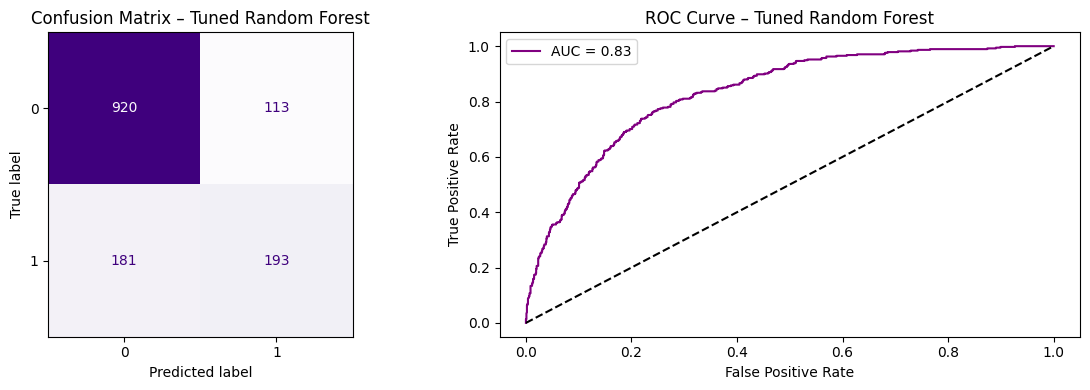

In [ ]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline, param_grid,
    cv=3, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

best_preds = grid_search.predict(X_test)
print(f"\nTuned Model Accuracy: {accuracy_score(y_test, best_preds)*100:.2f}%")

# Confusion Matrix + ROC side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds, ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Confusion Matrix – Tuned Random Forest')

rf_probs = grid_search.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
axes[1].plot(fpr, tpr, color='purple', label=f'AUC = {auc(fpr, tpr):.2f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve – Tuned Random Forest')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(grid_search.best_estimator_, 'churn_pipeline.pkl')
print("✅ Pipeline saved as churn_pipeline.pkl")

# Verify it works by loading and predicting
loaded_pipeline = joblib.load('churn_pipeline.pkl')
sample = X_test.iloc[:5]
predictions = loaded_pipeline.predict(sample)
print("\nSample Predictions (loaded pipeline):", predictions)
print("Actual Values:                        ", y_test.iloc[:5].values)

✅ Pipeline saved as churn_pipeline.pkl

Sample Predictions (loaded pipeline): [0 1 0 0 0]
Actual Values:                         [0 0 0 1 0]
